In [1]:
hotels <- read.csv("hotel_bookings.csv", header = TRUE)

In [2]:
head(hotels)

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,⋯,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
,<chr>,<int>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>,<chr>
1,Resort Hotel,0,342,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,737,2015,July,27,1,0,0,2,⋯,No Deposit,NULL,NULL,0,Transient,0,0,0,Check-Out,2015-07-01
3,Resort Hotel,0,7,2015,July,27,1,0,1,1,⋯,No Deposit,NULL,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,13,2015,July,27,1,0,1,1,⋯,No Deposit,304,NULL,0,Transient,75,0,0,Check-Out,2015-07-02
5,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03
6,Resort Hotel,0,14,2015,July,27,1,0,2,2,⋯,No Deposit,240,NULL,0,Transient,98,0,1,Check-Out,2015-07-03


In [3]:
library(dplyr)

hotels <- hotels %>%
  select(-arrival_date_year, -arrival_date_day_of_month, -agent, -company,-reservation_status,-reservation_status_date
        ,-country)

head(hotels)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,⋯,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
,<chr>,<int>,<int>,<chr>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<chr>,<chr>,<int>,<chr>,<int>,<chr>,<dbl>,<int>,<int>
1,Resort Hotel,0,342,July,27,0,0,2,0,0,⋯,0,C,C,3,No Deposit,0,Transient,0,0,0
2,Resort Hotel,0,737,July,27,0,0,2,0,0,⋯,0,C,C,4,No Deposit,0,Transient,0,0,0
3,Resort Hotel,0,7,July,27,0,1,1,0,0,⋯,0,A,C,0,No Deposit,0,Transient,75,0,0
4,Resort Hotel,0,13,July,27,0,1,1,0,0,⋯,0,A,A,0,No Deposit,0,Transient,75,0,0
5,Resort Hotel,0,14,July,27,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,98,0,1
6,Resort Hotel,0,14,July,27,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,98,0,1


In [4]:

hotels$hotel <- as.factor(hotels$hotel)
hotels$is_canceled <- as.factor(hotels$is_canceled)
hotels$arrival_date_month <- as.factor(hotels$arrival_date_month)
hotels$meal <- as.factor(hotels$meal)
hotels$market_segment <- as.factor(hotels$market_segment)
hotels$distribution_channel <- as.factor(hotels$distribution_channel)
hotels$is_repeated_guest <- as.factor(hotels$is_repeated_guest)
hotels$reserved_room_type <- as.factor(hotels$reserved_room_type)
hotels$assigned_room_type <- as.factor(hotels$assigned_room_type)
hotels$deposit_type <- as.factor(hotels$deposit_type)
hotels$customer_type <- as.factor(hotels$customer_type)

head(hotels)

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,⋯,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<dbl>,<int>,<int>
1,Resort Hotel,0,342,July,27,0,0,2,0,0,⋯,0,C,C,3,No Deposit,0,Transient,0,0,0
2,Resort Hotel,0,737,July,27,0,0,2,0,0,⋯,0,C,C,4,No Deposit,0,Transient,0,0,0
3,Resort Hotel,0,7,July,27,0,1,1,0,0,⋯,0,A,C,0,No Deposit,0,Transient,75,0,0
4,Resort Hotel,0,13,July,27,0,1,1,0,0,⋯,0,A,A,0,No Deposit,0,Transient,75,0,0
5,Resort Hotel,0,14,July,27,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,98,0,1
6,Resort Hotel,0,14,July,27,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,98,0,1


In [5]:

columns_of_interest <- c("lead_time", "stays_in_weekend_nights", "stays_in_week_nights",
                         "is_repeated_guest", "previous_cancellations", "deposit_type", "is_canceled")

head(hotels[ , columns_of_interest], 5)

,lead_time,stays_in_weekend_nights,stays_in_week_nights,is_repeated_guest,previous_cancellations,deposit_type,is_canceled
,<int>,<int>,<int>,<fct>,<int>,<fct>,<fct>
1,342,0,0,0,0,No Deposit,0
2,737,0,0,0,0,No Deposit,0
3,7,0,1,0,0,No Deposit,0
4,13,0,1,0,0,No Deposit,0
5,14,0,2,0,0,No Deposit,0


In [6]:
dim(hotels)

[1] 119390     25

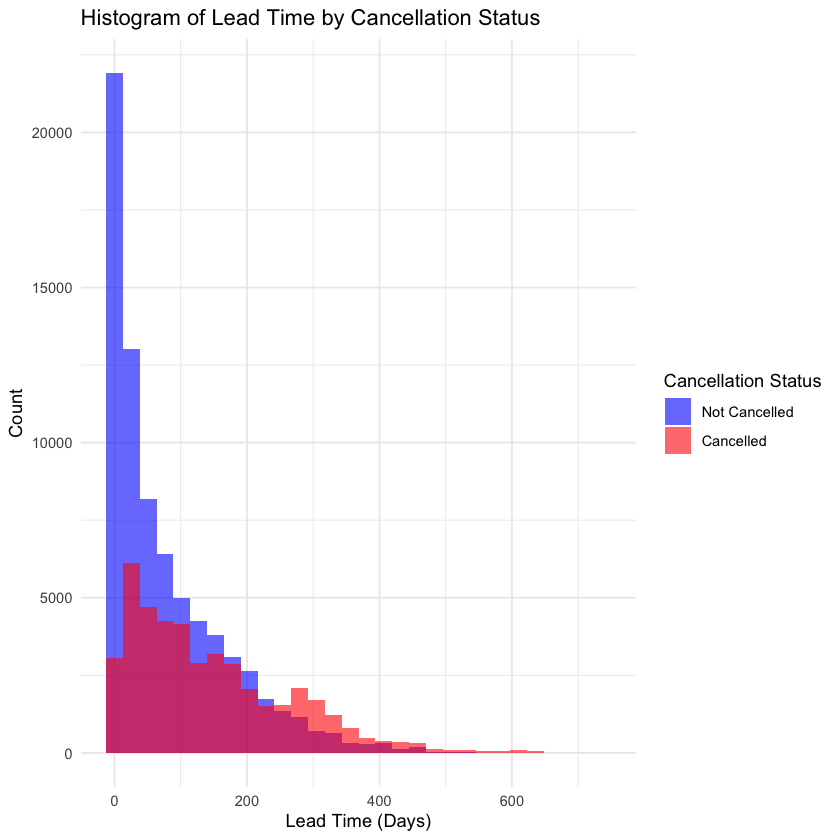

In [7]:
library(ggplot2)
ggplot(hotels, aes(x = lead_time, fill = factor(is_canceled))) +
  geom_histogram(bins = 30, alpha = 0.6, position = "identity") +
  scale_fill_manual(values = c("blue", "red"), labels = c("Not Cancelled", "Cancelled")) +
  labs(title = "Histogram of Lead Time by Cancellation Status",
       x = "Lead Time (Days)",
       y = "Count",
       fill = "Cancellation Status") +
  theme_minimal()

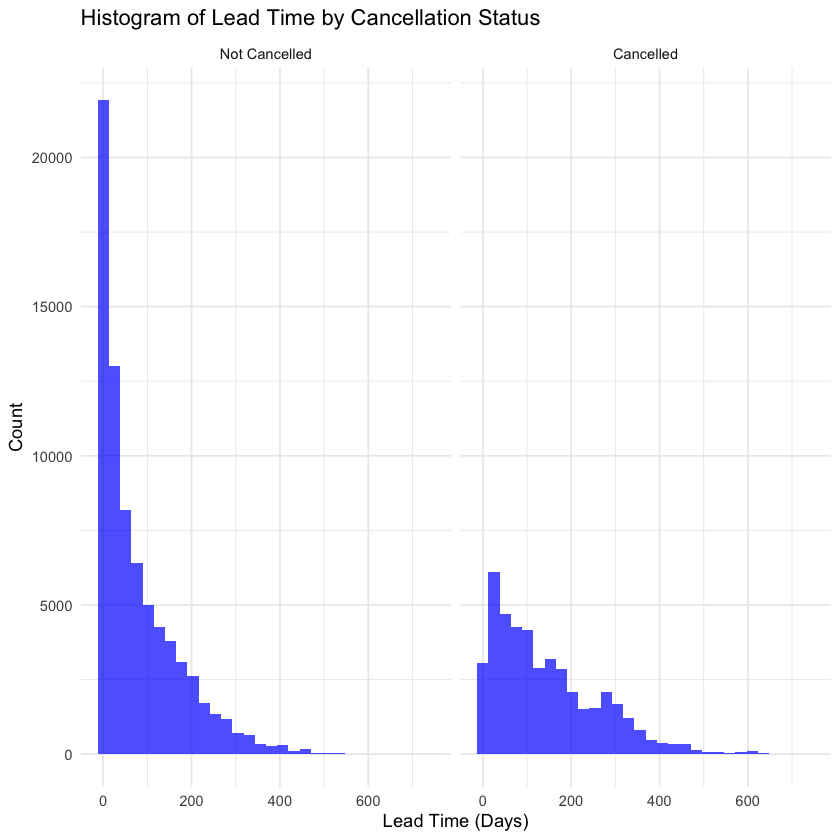

In [8]:
ggplot(hotels, aes(x = lead_time)) +
  geom_histogram(bins = 30, fill = "blue", alpha = 0.7) +
  facet_wrap(~is_canceled, labeller = as_labeller(c("0" = "Not Cancelled", "1" = "Cancelled"))) +
  labs(title = "Histogram of Lead Time by Cancellation Status",
       x = "Lead Time (Days)",
       y = "Count") +
  theme_minimal()

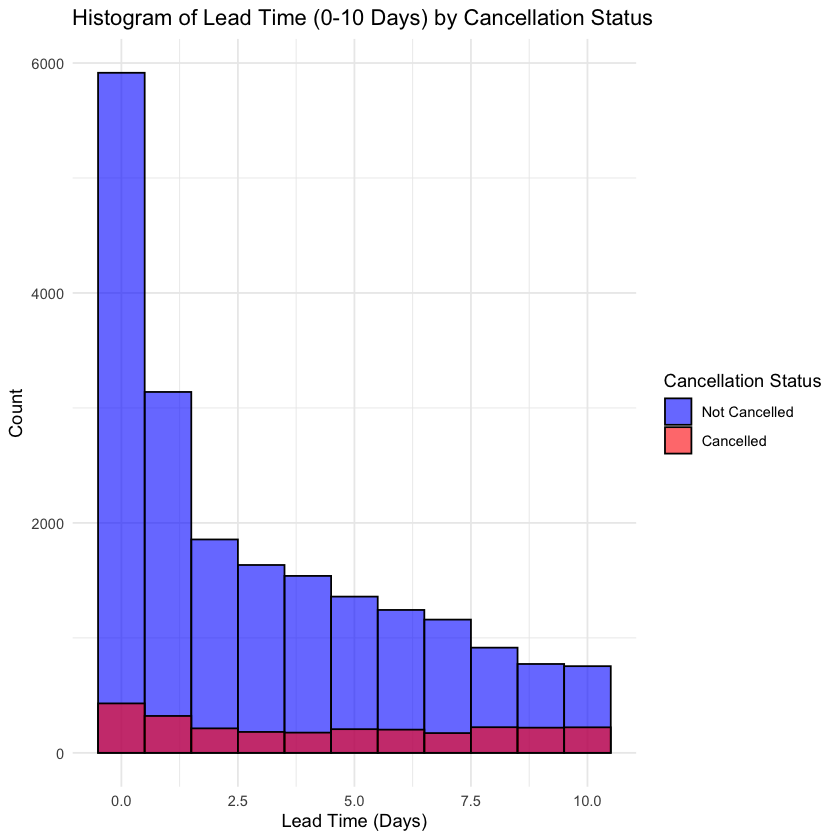

In [9]:

filtered_data <- subset(hotels, lead_time >= 0 & lead_time <= 10)

# Create histogram
ggplot(filtered_data, aes(x = lead_time, fill = factor(is_canceled))) +
  geom_histogram(binwidth = 1, alpha = 0.6, position = "identity", color = "black") +
  scale_fill_manual(values = c("blue", "red"), labels = c("Not Cancelled", "Cancelled")) +
  labs(title = "Histogram of Lead Time (0-10 Days) by Cancellation Status",
       x = "Lead Time (Days)",
       y = "Count",
       fill = "Cancellation Status") +
  theme_minimal()

In [10]:
unique(hotels$deposit_type)

[1] No Deposit Refundable Non Refund
Levels: No Deposit Non Refund Refundable

In [11]:
library(dplyr)

deposit_summary <- hotels %>%
  group_by(deposit_type, is_canceled) %>%
  summarise(count = n(), .groups = "drop")

print(deposit_summary)

# A tibble: 6 × 3
  deposit_type is_canceled count
  <fct>        <fct>       <int>
1 No Deposit   0           74947
2 No Deposit   1           29694
3 Non Refund   0              93
4 Non Refund   1           14494
5 Refundable   0             126
6 Refundable   1              36


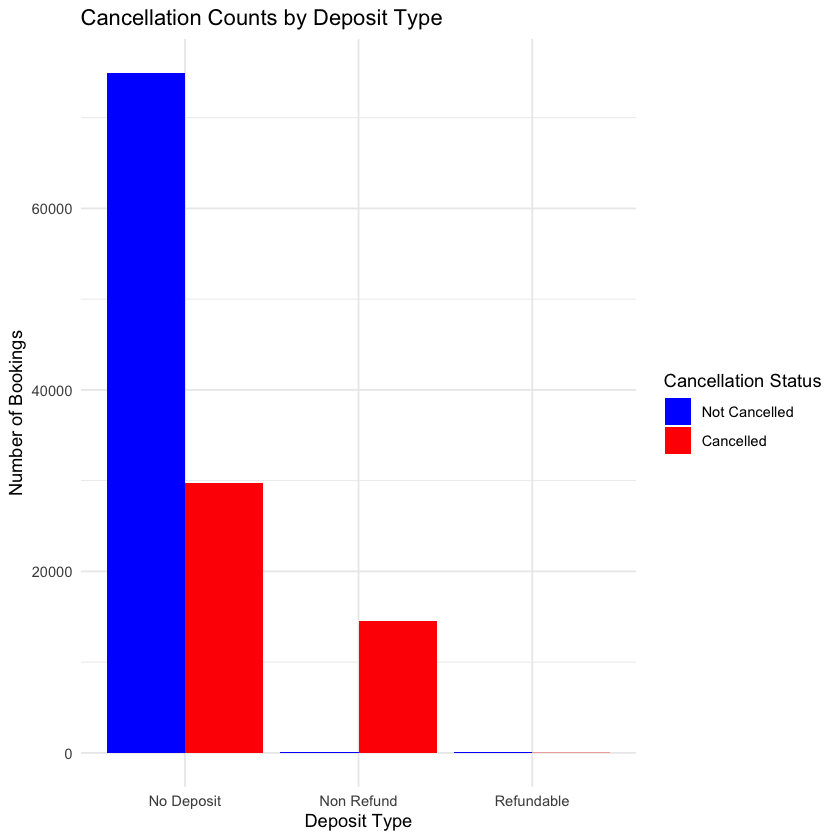

In [12]:
ggplot(deposit_summary, aes(x = deposit_type, y = count, fill = factor(is_canceled))) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("blue", "red"), labels = c("Not Cancelled", "Cancelled")) +
  labs(title = "Cancellation Counts by Deposit Type",
       x = "Deposit Type",
       y = "Number of Bookings",
       fill = "Cancellation Status") +
  theme_minimal()

In [13]:
set.seed(123)  

testRows_hotels <- sample(nrow(hotels), 0.2 * nrow(hotels))

testData_hotels <- hotels[testRows_hotels, ]
trainData_hotels <- hotels[-testRows_hotels, ]

head(trainData_hotels)

,hotel,is_canceled,lead_time,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,⋯,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
,<fct>,<fct>,<int>,<fct>,<int>,<int>,<int>,<int>,<int>,<int>,⋯,<int>,<fct>,<fct>,<int>,<fct>,<int>,<fct>,<dbl>,<int>,<int>
1,Resort Hotel,0,342,July,27,0,0,2,0,0,⋯,0,C,C,3,No Deposit,0,Transient,0,0,0
2,Resort Hotel,0,737,July,27,0,0,2,0,0,⋯,0,C,C,4,No Deposit,0,Transient,0,0,0
3,Resort Hotel,0,7,July,27,0,1,1,0,0,⋯,0,A,C,0,No Deposit,0,Transient,75,0,0
4,Resort Hotel,0,13,July,27,0,1,1,0,0,⋯,0,A,A,0,No Deposit,0,Transient,75,0,0
6,Resort Hotel,0,14,July,27,0,2,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,98,0,1
9,Resort Hotel,1,85,July,27,0,3,2,0,0,⋯,0,A,A,0,No Deposit,0,Transient,82,0,1


In [14]:

logistic_model <- glm(is_canceled ~ ., data = trainData_hotels, family = binomial)


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


In [15]:

logistic_preds <- predict(logistic_model, newdata = testData_hotels, type = "response")

logistic_class <- ifelse(logistic_preds > 0.5, 1, 0)

testing_error <- mean(logistic_class != testData_hotels$is_canceled)

cat("Testing Error:", testing_error, "\n")


Testing Error: 0.1886674 


In [22]:
colSums(is.na(trainData_hotels))

hotel                    is_canceled 
                             0                              0 
                     lead_time             arrival_date_month 
                             0                              0 
      arrival_date_week_number        stays_in_weekend_nights 
                             0                              0 
          stays_in_week_nights                         adults 
                             0                              0 
                      children                         babies 
                             4                              0 
                          meal                 market_segment 
                             0                              0 
          distribution_channel              is_repeated_guest 
                             0                              0 
        previous_cancellations previous_bookings_not_canceled 
                             0                              0 
            reserved_room_type             assigned_room_type 
                             0                              0 
               booking_changes                   deposit_type 
                             0                              0 
          days_in_waiting_list                  customer_type 
                             0                              0 
                           adr    required_car_parking_spaces 
                             0                              0 
     total_of_special_requests 
                             0

In [23]:
trainData_hotels <- na.omit(trainData_hotels)

In [27]:
library(randomForest)
library(caret)

set.seed(42)  # Ensure reproducibility

# Define cross-validation method
control <- trainControl(method = "cv", number = 5)  # 5-fold CV

# Define tuning grid for mtry
tune_grid <- expand.grid(mtry = c(2, 4, 6, 8))  # Try different values of mtry

# Train Random Forest with Cross-Validation
rf_cv_model <- train(
  is_canceled ~ ., 
  data = trainData_hotels, 
  method = "rf", 
  trControl = control, 
  tuneGrid = tune_grid, 
  ntree = 100  # Fixed number of trees
)


In [28]:
print(rf_cv_model$bestTune)

  mtry
4    8


In [29]:
rf_model_4 <- randomForest(is_canceled ~ ., data = trainData_hotels, mtry = 4, ntree = 100)

In [31]:
rf_preds_4 <- predict(rf_model_4, newdata = testData_hotels)
test_error_4 <- mean(rf_preds_4 != testData_hotels$is_canceled)
test_error_4

[1] 0.1392076

In [33]:
#install.packages("xgboost")


The downloaded binary packages are in
	/var/folders/2w/wnk720616bg0v2kgsxpk3qfr0000gn/T//RtmpgDhbUh/downloaded_packages


In [40]:
library(xgboost)

trainData_hotels$is_canceled <- as.factor(trainData_hotels$is_canceled)
testData_hotels$is_canceled <- as.factor(testData_hotels$is_canceled)

train_matrix <- model.matrix(is_canceled ~ . -1, data = trainData_hotels)
test_matrix <- model.matrix(is_canceled ~ . -1, data = testData_hotels)

train_labels <- trainData_hotels$is_canceled
test_labels <- testData_hotels$is_canceled

str(train_labels)  


 Factor w/ 2 levels "0","1": 1 1 1 1 1 2 2 1 1 1 ...


In [46]:
xgb_grid <- expand.grid(
  nrounds = c(50, 75, 100),   
  eta = c(0.01, 0.1),        
  max_depth = c(3, 6) ,   
  gamma = 0, colsample_bytree = 1, min_child_weight = 1, subsample = 1
)



xgb_control <- trainControl(method = "cv", number = 5)

In [47]:

xgb_cv_model <- train(
  x = train_matrix, y = train_labels,  
  method = "xgbTree",
  trControl = xgb_control,
  tuneGrid = xgb_grid
)

print(xgb_cv_model$bestTune)

[13:17:20] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:20] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:34] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:41] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:41] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:56] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:17:56] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:18:03] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is deprecated, use `iteration_range` instead.
[13:18:03] WARNING: src/c_api/c_api.cc:935: `ntree_limit` is dep

In [48]:
xgb_cv_model$bestTune

,nrounds,max_depth,eta,gamma,colsample_bytree,min_child_weight,subsample
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
12,100,6,0.1,0,1,1,1


In [55]:
xgb_preds <- predict(xgb_cv_model, newdata = test_matrix)

xgb_test_error <- mean(xgb_preds != test_labels)



In [56]:
xgb_test_error

[1] 0.1697797